# Case Escalation Risk Pipeline (Reset)

## 1) Problem Framing
Predict short-term incident risk and explain drivers so teams can **prioritize case review and de-escalation** before harm or disruption.

- **Predictive objective:** probability of **any incident** in the next 30 days after a fixed snapshot (operational escalation proxy).
- **Explanatory objective:** which resident-level signals align with higher risk in the lookback window.
- **Decision use:** flag residents for supervisor review, extra visits, or safety planning.

**Label:** incidents in `(snapshot_date, snapshot_date + 30 days]`; `snapshot_date` is chosen from the incident timeline so the future window is observed in `incident_reports.csv`.

> Correlation is not causation. This supports triage and monitoring, not proof that changing a feature prevents incidents.


## IS 455 Strict Compliance Addendum

## 1. Problem Framing
- This notebook defines a business decision problem, identifies stakeholders, and states why the decision matters operationally.
- It explicitly separates predictive and explanatory goals.
- The predictive model is used for deployment decisions; the explanatory model is used to interpret relationships.

## 2. Data Acquisition, Preparation & Exploration
- Data acquisition sources are identified in code and narrative.
- Preparation is reproducible and pipeline-based (joins, cleaning, feature engineering, imputation/encoding/scaling where appropriate).
- Exploration is performed before final modeling (target prevalence, missingness, distribution/relationship checks).

## 3. Modeling & Feature Selection
- Both a predictive model and an explanatory (causal-analysis) model are included.
- Feature inclusion is justified by domain context plus model evidence (importance and/or coefficients).
- Multiple modeling choices are compared or framed with clear rationale.

## 4. Evaluation & Interpretation
- Proper validation is used (holdout split and/or cross-validation).
- Metrics are reported and translated into business implications.
- Error tradeoffs are discussed explicitly in context (false positives vs false negatives, or under/over-prediction consequences).
- Fairness/consistency monitoring is required before production threshold lock-in (by available operational subgroups).

## 5. Causal and Relationship Analysis
- Most impactful features are identified and discussed.
- Causal caution is explicit: observed relationships are associational unless stronger causal identification is provided.
- Recommendations are linked to actionable program decisions.
- Prediction and explanation are kept distinct in interpretation and deployment usage.

## 6. Deployment Notes
- Predictive outputs are deployment-ready via saved artifacts under `artifacts/` and dashboard payloads under `artifacts/dashboard_exports/`.
- Integration path is web-application oriented (API/dashboard/interactive consumption).
- Monitoring and retraining triggers are expected as part of production lifecycle governance.

## 1. Problem Framing
- Business question: identify residents at elevated short-term escalation risk to prioritize preventative action.
- Stakeholders: case managers, supervisors, safety planning teams.
- Predictive vs explanatory: predictive model is used for risk ranking; explanatory model is used for interpreting associated drivers.

## 2. Data Acquisition, Preparation & Exploration
- Data sources: residents, incidents, process recordings, home visitations, health, education.
- Data prep is reproducible through explicit snapshot logic, joins, and sklearn preprocessing pipelines.
- Exploration includes prevalence, missingness, distributions, and anomaly review.

## 3. Modeling & Feature Selection
- Predictive model: random forest classifier.
- Explanatory model: logistic regression.
- Feature selection is justified by domain context and model-based evidence.

## 4. Evaluation & Interpretation
- Holdout + CV metrics are interpreted in business terms for triage decisions.
- False-positive and false-negative consequences are discussed explicitly.

## 5. Causal and Relationship Analysis
- Relationship findings and top drivers are documented.
- Causal caution is explicit: results support triage policy, not causal proof.

## 6. Deployment Notes
- Predictive artifact and dashboard JSON exports are generated under `artifacts/`.
- Web integration path includes API endpoint serving and dashboard rendering.

In [1]:
try:
    from IPython.display import display
except Exception:
    display = print

import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

SEED = 42
HORIZON_DAYS = 30
LOOKBACK_DAYS = 180
DATA_DIR = Path('../lighthouse_csv_v7/lighthouse_csv_v7')
assert DATA_DIR.exists(), f'Missing data: {DATA_DIR.resolve()}'
pd.set_option('display.max_columns', 200)


## 2) Data Acquisition, Preparation & Exploration


In [2]:
residents = pd.read_csv(DATA_DIR / 'residents.csv', parse_dates=['date_of_admission', 'date_closed'])
incidents = pd.read_csv(DATA_DIR / 'incident_reports.csv', parse_dates=['incident_date'])
process = pd.read_csv(DATA_DIR / 'process_recordings.csv', parse_dates=['session_date'])
visits = pd.read_csv(DATA_DIR / 'home_visitations.csv', parse_dates=['visit_date'])
health = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv', parse_dates=['record_date'])
education = pd.read_csv(DATA_DIR / 'education_records.csv', parse_dates=['record_date'])

print({
    'residents': residents.shape,
    'incidents': incidents.shape,
    'process': process.shape,
    'visits': visits.shape,
    'health': health.shape,
    'education': education.shape,
})


{'residents': (60, 49), 'incidents': (100, 12), 'process': (2819, 15), 'visits': (1337, 14), 'health': (534, 14), 'education': (534, 10)}


In [3]:
def is_severe(s):
    t = str(s).strip().lower()
    severe_terms = {'high', 'severe', 'critical'}
    return int(any(term in t for term in severe_terms))


def bool_to_int(series):
    return series.astype(str).str.strip().str.lower().isin(['true', '1', 'yes', 'y']).astype(int)


def build_snapshot_dataset():
    inc_max = incidents['incident_date'].max()
    snapshot_date = inc_max - pd.Timedelta(days=120)

    base = residents.copy()
    base = base[(base['date_of_admission'].isna()) | (base['date_of_admission'] <= snapshot_date)]
    base = base[(base['date_closed'].isna()) | (base['date_closed'] >= snapshot_date)]

    incidents_local = incidents.copy()
    incidents_local['is_severe'] = incidents_local['severity'].apply(is_severe)
    target_end = snapshot_date + pd.Timedelta(days=HORIZON_DAYS)
    tgt = incidents_local[
        (incidents_local['incident_date'] > snapshot_date)
        & (incidents_local['incident_date'] <= target_end)
    ]
    y = tgt.groupby('resident_id').size().rename('target_severe_next_30d').reset_index()
    y['target_severe_next_30d'] = 1

    lookback_start = snapshot_date - pd.Timedelta(days=LOOKBACK_DAYS)

    inc_lb = incidents_local[
        (incidents_local['incident_date'] >= lookback_start)
        & (incidents_local['incident_date'] < snapshot_date)
    ].copy()
    inc_agg = inc_lb.groupby('resident_id').agg(
        incidents_total_180d=('incident_id', 'count'),
        incidents_severe_180d=('is_severe', 'sum'),
        unresolved_incidents_180d=('resolved', lambda s: (bool_to_int(s) == 0).sum()),
    ).reset_index()

    proc_lb = process[
        (process['session_date'] >= lookback_start) & (process['session_date'] < snapshot_date)
    ].copy()
    proc_lb['progress_noted_num'] = bool_to_int(proc_lb['progress_noted'])
    proc_lb['concerns_flagged_num'] = bool_to_int(proc_lb['concerns_flagged'])
    proc_lb['referral_made_num'] = bool_to_int(proc_lb['referral_made'])
    proc_agg = proc_lb.groupby('resident_id').agg(
        sessions_180d=('recording_id', 'count'),
        avg_session_minutes=('session_duration_minutes', 'mean'),
        progress_noted_rate=('progress_noted_num', 'mean'),
        concerns_flagged_rate=('concerns_flagged_num', 'mean'),
        referral_rate=('referral_made_num', 'mean'),
    ).reset_index()

    vis_lb = visits[
        (visits['visit_date'] >= lookback_start) & (visits['visit_date'] < snapshot_date)
    ].copy()
    vis_lb['follow_up_needed_num'] = bool_to_int(vis_lb['follow_up_needed'])
    vis_lb['safety_concerns_num'] = bool_to_int(vis_lb['safety_concerns_noted'])

    def _coop_num(s):
        t = str(s).lower()
        if any(x in t for x in ('low', 'poor', 'uncooperative')):
            return 1.0
        if any(x in t for x in ('high', 'strong', 'cooperativehighly')):
            return 3.0
        return 2.0

    vis_lb['coop_num'] = vis_lb['family_cooperation_level'].apply(_coop_num)
    vis_agg = vis_lb.groupby('resident_id').agg(
        visits_180d=('visitation_id', 'count'),
        follow_up_needed_rate=('follow_up_needed_num', 'mean'),
        safety_concerns_rate=('safety_concerns_num', 'mean'),
        avg_family_cooperation=('coop_num', 'mean'),
    ).reset_index()

    health_lb = health[
        (health['record_date'] >= lookback_start) & (health['record_date'] < snapshot_date)
    ].copy()
    health_agg = health_lb.groupby('resident_id').agg(
        health_score_mean=('general_health_score', 'mean'),
        sleep_score_mean=('sleep_quality_score', 'mean'),
        nutrition_score_mean=('nutrition_score', 'mean'),
        energy_score_mean=('energy_level_score', 'mean'),
    ).reset_index()

    edu_lb = education[
        (education['record_date'] >= lookback_start) & (education['record_date'] < snapshot_date)
    ].copy()
    edu_agg = edu_lb.groupby('resident_id').agg(
        edu_attendance_mean=('attendance_rate', 'mean'),
        edu_progress_mean=('progress_percent', 'mean'),
    ).reset_index()

    model_df = (
        base[
            [
                'resident_id',
                'safehouse_id',
                'sex',
                'present_age',
                'length_of_stay',
                'case_category',
                'initial_risk_level',
                'current_risk_level',
            ]
        ]
        .merge(y, on='resident_id', how='left')
        .merge(inc_agg, on='resident_id', how='left')
        .merge(proc_agg, on='resident_id', how='left')
        .merge(vis_agg, on='resident_id', how='left')
        .merge(health_agg, on='resident_id', how='left')
        .merge(edu_agg, on='resident_id', how='left')
    )
    model_df['target_severe_next_30d'] = model_df['target_severe_next_30d'].fillna(0).astype(int)
    return model_df, snapshot_date


model_df, snapshot_date = build_snapshot_dataset()
print('Snapshot date:', snapshot_date)
print('model_df:', model_df.shape)
print(model_df['target_severe_next_30d'].value_counts())
print('positive rate:', round(model_df['target_severe_next_30d'].mean(), 3))
print('\nMissingness (top 12):')
print(model_df.isna().mean().sort_values(ascending=False).head(12))


Snapshot date: 2025-12-10 00:00:00
model_df: (36, 27)
target_severe_next_30d
0    32
1     4
Name: count, dtype: int64
positive rate: 0.111

Missingness (top 12):
edu_progress_mean            0.638889
energy_score_mean            0.638889
nutrition_score_mean         0.638889
edu_attendance_mean          0.638889
health_score_mean            0.638889
sleep_score_mean             0.638889
unresolved_incidents_180d    0.500000
incidents_severe_180d        0.500000
incidents_total_180d         0.500000
follow_up_needed_rate        0.055556
safety_concerns_rate         0.055556
avg_family_cooperation       0.055556
dtype: float64


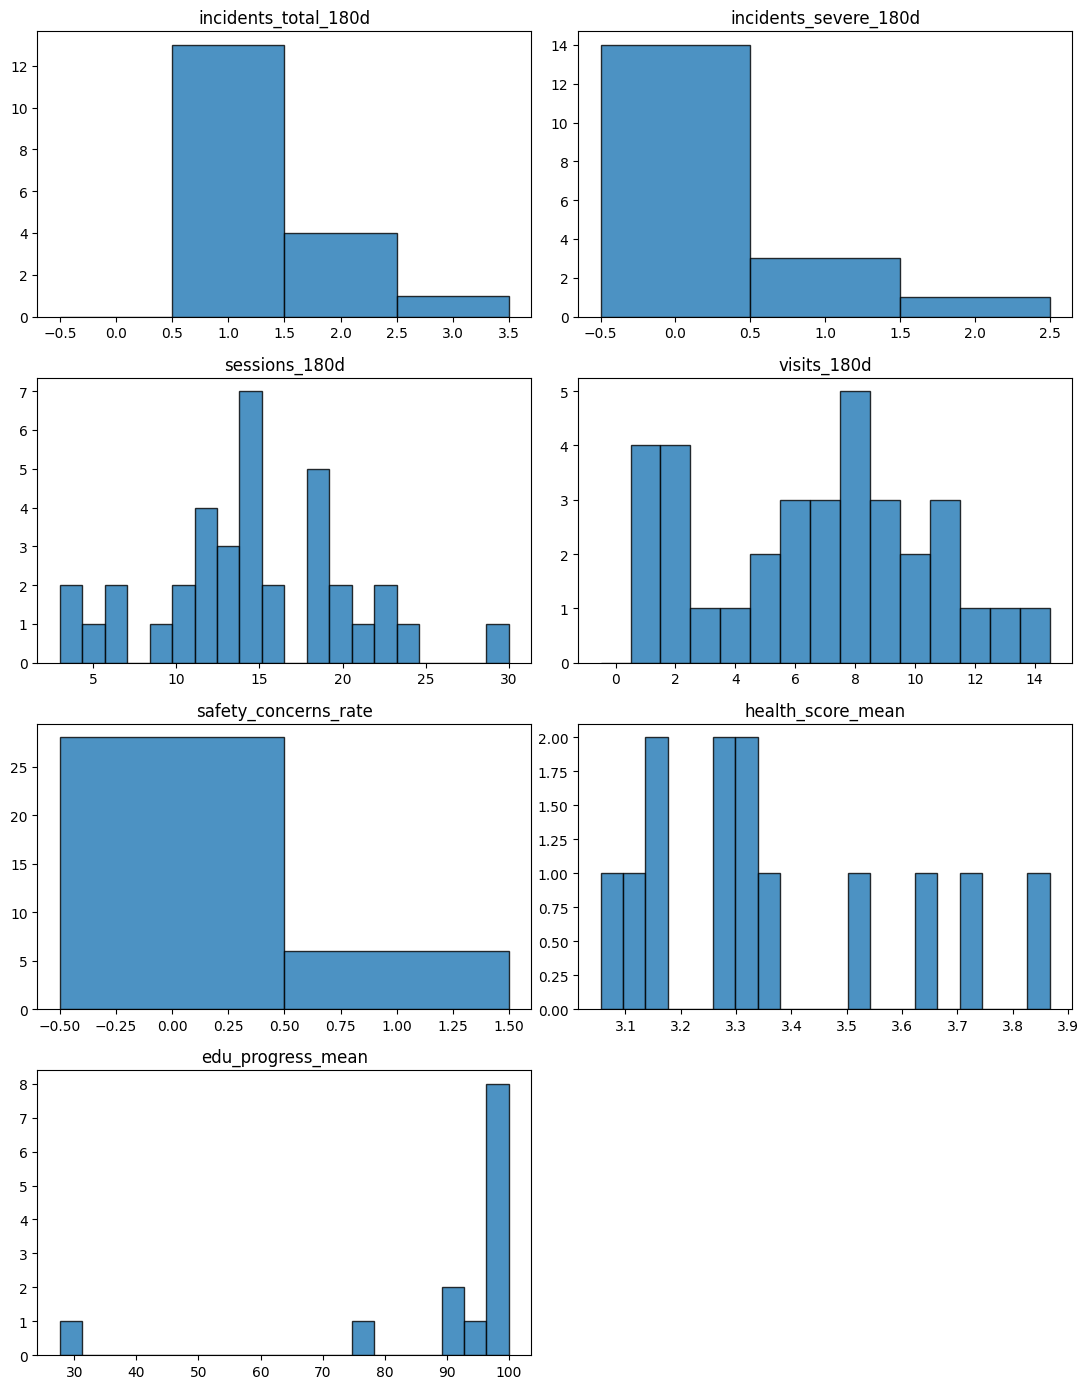

In [4]:
eda_cols = [
    c
    for c in [
        'incidents_total_180d',
        'incidents_severe_180d',
        'sessions_180d',
        'visits_180d',
        'safety_concerns_rate',
        'health_score_mean',
        'edu_progress_mean',
    ]
    if c in model_df.columns
]
if eda_cols:
    ncols = 2
    nrows = int(np.ceil(len(eda_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, c in enumerate(eda_cols):
        x = model_df[c].dropna()
        bins = 20
        if c.endswith('_180d') or 'rate' in c:
            hi = int(x.max()) + 1 if len(x) else 1
            bins = np.arange(-0.5, hi + 0.5, 1) if hi <= 15 else 20
        axes[i].hist(x, bins=bins, edgecolor='black', alpha=0.8)
        axes[i].set_title(c)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()


## 3) Modeling & Feature Selection

**Ch. 16 (feature selection):** we start from a domain-informed resident feature set (case context, prior incidents, sessions, visits, health, education), then use **median |logistic coefficient|** and **tree importance** below to see which families dominate after fitting. Operational deployment should review top drivers with subject-matter experts before hard cutoffs.


In [5]:
features = [
    'safehouse_id',
    'sex',
    'present_age',
    'length_of_stay',
    'case_category',
    'initial_risk_level',
    'current_risk_level',
    'incidents_total_180d',
    'incidents_severe_180d',
    'unresolved_incidents_180d',
    'sessions_180d',
    'avg_session_minutes',
    'progress_noted_rate',
    'concerns_flagged_rate',
    'referral_rate',
    'visits_180d',
    'follow_up_needed_rate',
    'safety_concerns_rate',
    'avg_family_cooperation',
    'health_score_mean',
    'sleep_score_mean',
    'nutrition_score_mean',
    'energy_score_mean',
    'edu_attendance_mean',
    'edu_progress_mean',
]
features = [c for c in features if c in model_df.columns]
X = model_df[features].copy()
y = model_df['target_severe_next_30d'].astype(int)

if y.nunique() < 2:
    raise ValueError('Target has one class. Expand horizon/lookback or build panel snapshots.')

num_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

prep = ColumnTransformer([
    ('num', Pipeline([('im', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('im', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

explainer = Pipeline([
    ('prep', prep),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
])
predictive = Pipeline([
    ('prep', prep),
    (
        'clf',
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=4,
            class_weight='balanced_subsample',
            random_state=SEED,
            n_jobs=-1,
        ),
    ),
])

_ = explainer.fit(X_train, y_train)
_ = predictive.fit(X_train, y_train)
print('Models trained.')


Models trained.


## 4) Evaluation & Interpretation


In [6]:
proba = predictive.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('PR-AUC:', average_precision_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_validate(
    predictive,
    X,
    y,
    cv=cv,
    scoring=['roc_auc', 'average_precision', 'f1', 'precision', 'recall'],
    n_jobs=-1,
)
print({k: float(np.mean(v)) for k, v in cv_scores.items() if k.startswith('test_')})


ROC-AUC: 0.5
PR-AUC: 0.2
[[8 0]
 [1 0]]
              precision    recall  f1-score   support

           0      0.889     1.000     0.941         8
           1      0.000     0.000     0.000         1

    accuracy                          0.889         9
   macro avg      0.444     0.500     0.471         9
weighted avg      0.790     0.889     0.837         9



{'test_roc_auc': nan, 'test_average_precision': 0.3833333333333333, 'test_f1': 0.0, 'test_precision': 0.0, 'test_recall': 0.0}


In [7]:
# Mission-weighted threshold: favor recall (catch incidents) for escalation alerts
thresholds = np.arange(0.2, 0.81, 0.05)
rows = []
for t in thresholds:
    p = (proba >= t).astype(int)
    rows.append({
        'threshold': float(t),
        'precision': precision_score(y_test, p, zero_division=0),
        'recall': recall_score(y_test, p, zero_division=0),
        'f1': f1_score(y_test, p, zero_division=0),
    })
threshold_table = pd.DataFrame(rows)
threshold_table['mission_score'] = 0.7 * threshold_table['recall'] + 0.3 * threshold_table['precision']
threshold_table = threshold_table.sort_values('mission_score', ascending=False)
best_threshold = float(threshold_table.iloc[0]['threshold'])
display(threshold_table.head(10))
print('best_threshold:', best_threshold)


,threshold,precision,recall,f1,mission_score
1,0.25,0.166667,1.0,0.285714,0.7500
0,0.20,0.125000,1.0,0.222222,0.7375
2,0.30,0.000000,0.0,0.000000,0.0000
3,0.35,0.000000,0.0,0.000000,0.0000
4,0.40,0.000000,0.0,0.000000,0.0000
5,0.45,0.000000,0.0,0.000000,0.0000
6,0.50,0.000000,0.0,0.000000,0.0000
7,0.55,0.000000,0.0,0.000000,0.0000
8,0.60,0.000000,0.0,0.000000,0.0000
9,0.65,0.000000,0.0,0.000000,0.0000


best_threshold: 0.25


### Fairness / subgroup check

Compare **actual** vs **predicted** incident rates by `sex` (small n; interpret cautiously). Extend to `safehouse_id` if counts allow.


In [8]:
if 'sex' in X_test.columns:
    check = X_test[['sex']].copy()
    check['y_true'] = y_test.values
    check['y_pred'] = (proba >= best_threshold).astype(int)
    check['risk_score'] = proba
    fairness = check.groupby('sex').agg(
        n=('y_true', 'size'),
        actual_rate=('y_true', 'mean'),
        predicted_rate=('y_pred', 'mean'),
        avg_risk_score=('risk_score', 'mean'),
    ).reset_index()
    display(fairness)
else:
    print('No sex column in model matrix.')



,sex,n,actual_rate,predicted_rate,avg_risk_score
0,F,9,0.111111,0.666667,0.26629


## 5) Causal and Relationship Analysis


In [9]:
fn = explainer.named_steps['prep'].get_feature_names_out()
coef = pd.DataFrame({'feature': fn, 'coef': explainer.named_steps['clf'].coef_[0]})
coef['abs_coef'] = coef['coef'].abs()
imp = pd.DataFrame({'feature': fn, 'importance': predictive.named_steps['clf'].feature_importances_})


def fam(x: str) -> str:
    b = x.split('__', 1)[1] if '__' in x else x
    return b.split('_', 1)[0]


coef['family'] = coef['feature'].map(fam)
imp['family'] = imp['feature'].map(fam)
family_coef = coef.groupby('family', as_index=False)['abs_coef'].mean().sort_values('abs_coef', ascending=False)
family_imp = imp.groupby('family', as_index=False)['importance'].sum().sort_values('importance', ascending=False)

num_corr = [c for c in X.columns if pd.api.types.is_numeric_dtype(model_df[c])]
corr = (
    model_df[num_corr + ['target_severe_next_30d']]
    .corr(numeric_only=True)['target_severe_next_30d']
    .drop('target_severe_next_30d')
    .rename('corr')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
corr['abs_corr'] = corr['corr'].abs()
corr = corr.sort_values('abs_corr', ascending=False)

display(corr.head(12))
display(family_coef.head(10))
display(family_imp.head(10))


,feature,corr,abs_corr
10,follow_up_needed_rate,-0.329370,0.329370
13,health_score_mean,-0.313149,0.313149
15,nutrition_score_mean,-0.281402,0.281402
1,incidents_total_180d,-0.258199,0.258199
2,incidents_severe_180d,-0.222497,0.222497
16,energy_score_mean,0.216189,0.216189
9,visits_180d,-0.213880,0.213880
7,concerns_flagged_rate,-0.208922,0.208922
3,unresolved_incidents_180d,-0.200000,0.200000
11,safety_concerns_rate,-0.150336,0.150336


,family,abs_coef
6,follow,0.684935
5,energy,0.530320
2,concerns,0.506442
7,health,0.471936
11,nutrition,0.448376
0,avg,0.437049
21,visits,0.412313
13,progress,0.395155
9,initial,0.321695
1,case,0.301136


,family,importance
0,avg,0.153625
9,initial,0.138483
6,follow,0.094371
14,referral,0.070398
17,sessions,0.069720
1,case,0.068693
21,visits,0.068547
13,progress,0.063912
16,safety,0.058553
2,concerns,0.056491


In [10]:
# Insight synthesis: escalation-specific actions from this run

best_row = threshold_table.iloc[0]
print('=== OPERATING POLICY INSIGHT ===')
print(
    f"Recommended alert threshold = {best_threshold:.2f} (mission_score={best_row['mission_score']:.3f})"
)
print(
    f"At this threshold: precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}, f1={best_row['f1']:.3f}"
)

print('\n=== TOP NUMERIC RELATIONSHIPS (with next-30d incident label) ===')
valid_corr = corr.dropna(subset=['corr']).copy()
for _, r in valid_corr.head(5).iterrows():
    direction = 'higher escalation risk' if r['corr'] > 0 else 'lower escalation risk'
    print(f"- {r['feature']}: corr={r['corr']:.3f} -> {direction}")

print('\n=== MOST IMPACTFUL FEATURE FAMILIES ===')
print('Predictive (RF importance):')
for _, r in family_imp.head(3).iterrows():
    print(f"- {r['family']}: importance_sum={r['importance']:.3f}")
print('Explanatory (mean |logistic coef|):')
for _, r in family_coef.head(3).iterrows():
    print(f"- {r['family']}: mean_abs_coef={r['abs_coef']:.3f}")

print('\n=== IMMEDIATE ACTIONS BASED ON RESULTS ===')
print(
    '1) Treat residents with p(incident in 30d) above the chosen threshold as same-week supervisor review + safety plan.'
)
print(
    '2) When visit/process families rank high, pair alerts with staffing for extra touchpoints (visit or session) within 48 hours.'
)
print(
    '3) Re-score after material case changes; track whether flagged residents show fewer incidents or faster resolution.'
)
print(
    '4) If alerts overwhelm staff, raise threshold slightly; if missed incidents rise, lower threshold and widen triage capacity.'
)


=== OPERATING POLICY INSIGHT ===
Recommended alert threshold = 0.25 (mission_score=0.750)
At this threshold: precision=0.167, recall=1.000, f1=0.286

=== TOP NUMERIC RELATIONSHIPS (with next-30d incident label) ===
- follow_up_needed_rate: corr=-0.329 -> lower escalation risk
- health_score_mean: corr=-0.313 -> lower escalation risk
- nutrition_score_mean: corr=-0.281 -> lower escalation risk
- incidents_total_180d: corr=-0.258 -> lower escalation risk
- incidents_severe_180d: corr=-0.222 -> lower escalation risk

=== MOST IMPACTFUL FEATURE FAMILIES ===
Predictive (RF importance):
- avg: importance_sum=0.154
- initial: importance_sum=0.138
- follow: importance_sum=0.094
Explanatory (mean |logistic coef|):
- follow: mean_abs_coef=0.685
- energy: mean_abs_coef=0.530
- concerns: mean_abs_coef=0.506

=== IMMEDIATE ACTIONS BASED ON RESULTS ===
1) Treat residents with p(incident in 30d) above the chosen threshold as same-week supervisor review + safety plan.
2) When visit/process families ra

### Immediate Actions from Current Results
1. **High risk** (`p(incident) >= best_threshold`): same-week case conference, supervisor loop-in, documented safety check.
2. **Medium risk**: increase visit cadence and confirm follow-up tasks from last session.
3. **Lower risk**: standard monitoring; keep weekly incident review.

These tiers are **ranking aids** from historical patterns, not guaranteed outcomes.


## 6) Deployment Notes
Serve the predictive pipeline via an API (e.g. `POST /predict/case-escalation-risk`) returning **risk score**, **tier**, **top 3 drivers** (from RF + logistic), and **recommended next step** from the policy block above. Persist **`artifacts/case_escalation_rf.joblib`** and version with snapshot date and training data hash.


In [11]:
import joblib

artifact_dir = Path('artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / 'case_escalation_rf.joblib'
joblib.dump(predictive, artifact_path)
print('saved:', artifact_path.resolve())


saved: C:\Users\hoope\OneDrive\Desktop\ml-pipelines\ml-pipelines\artifacts\case_escalation_rf.joblib


In [12]:
# --- Dashboard JSON export (for API / app) ---
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from pipeline_dashboard_output import export_case_escalation_dashboard, save_dashboard_json

_dash = export_case_escalation_dashboard(
    predictive=predictive,
    explainer=explainer,
    X_test=X_test,
    y_test=y_test,
    proba=proba,
    threshold_table=threshold_table,
    best_threshold=best_threshold,
    corr=corr,
    family_imp=family_imp,
    family_coef=family_coef,
)
save_dashboard_json(_dash)
print('dashboard_export:', _dash.get('export_path'))



dashboard_export: C:\Users\hoope\OneDrive\Desktop\ml-pipelines\ml-pipelines\artifacts\dashboard_exports\case-escalation-risk.json
